# Football Analytics — Premier League 2023/24
### A Complete Data Analysis Project
**Tools:** Python · Pandas · SQL · Statistics · Plotly

---

## Objective
Analyze Premier League 2023/24 player and match data to:
- Identify the most efficient scorers adjusted for position
- Expose penalty inflation in raw goal rankings
- Find undervalued players invisible to traditional metrics
- Statistically prove whether home advantage is real

**Dataset:** Premier League 23/24 Stats (Kaggle) — 298 players, 381 matches
**Author:** Bilge Han Erduran
**GitHub:** github.com/bherduran

In [28]:
# Core libraries
import pandas as pd
import numpy as np
from scipy import stats
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Display settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Setup complete")

Setup complete


## 1. Data Loading & Preparation
Loading four datasets: player scoring, player assists, match results, and player positions.
All data sourced from Premier League 2023/24 season.
Player positions dataset manually curated to enable position-adjusted analysis.

In [29]:
# Load datasets
df_scorers = pd.read_csv('player_top_scorers.csv')
df_assists = pd.read_csv('player_top_assists.csv')
df_matches = pd.read_csv('matches_23_24.csv')
df_positions = pd.read_csv('player_positions.csv')

# Quick validation
print(f"Scorers dataset:  {df_scorers.shape[0]} players")
print(f"Assists dataset:  {df_assists.shape[0]} players")
print(f"Matches dataset:  {df_matches.shape[0]} matches")
print(f"Positions dataset:{df_positions.shape[0]} players")

Scorers dataset:  298 players
Assists dataset:  283 players
Matches dataset:  381 matches
Positions dataset:300 players


In [30]:
# Clean matches data
df_matches = df_matches.drop(columns=["Unnamed: 11", "Unnamed: 12"])
df_matches["Score"] = df_matches["Score"].str.replace(" ", "")
df_matches[["Home Goals", "Away Goals"]] = df_matches["Score"].str.split("_", expand=True)
df_matches["Home Goals"] = pd.to_numeric(df_matches["Home Goals"], errors="coerce")
df_matches["Away Goals"] = pd.to_numeric(df_matches["Away Goals"], errors="coerce")
df_matches = df_matches[df_matches["Finished"] == True].copy()
df_matches = df_matches[["Round", "Home Team", "Home Goals", "Away Goals", "Away Team", "UTC Time", "Match Status"]]

# Create metrics for scorers
df_scorers["non_penalty_goals"] = df_scorers["Goals"] - df_scorers["Penalties"]
df_scorers["goals_per_90"] = round((df_scorers["Goals"] / df_scorers["Minutes"]) * 90, 2)
df_scorers["non_penalty_per_90"] = round((df_scorers["non_penalty_goals"] / df_scorers["Minutes"]) * 90, 2)

# Filter qualified players (900+ minutes)
df_qualified = df_scorers[df_scorers["Minutes"] >= 900].copy()

# Merge all datasets
df_scorers_merged = pd.merge(
    df_qualified[["Player", "Team", "Country", "Goals", "Penalties", "Minutes",
                  "goals_per_90", "non_penalty_goals", "non_penalty_per_90"]],
    df_assists[["Player", "Assists", "Secondary Assists"]],
    on="Player", how="inner"
)

df_scorers_merged["assists_per_90"] = round((df_scorers_merged["Assists"] / df_scorers_merged["Minutes"]) * 90, 2)
df_scorers_merged["goal_contributions"] = df_scorers_merged["Goals"] + df_scorers_merged["Assists"]
df_scorers_merged["contributions_per_90"] = round((df_scorers_merged["goal_contributions"] / df_scorers_merged["Minutes"]) * 90, 2)

df_complete = pd.merge(df_scorers_merged, df_positions, on="Player", how="inner")
df_complete["Goals_Rank"] = df_complete["Goals"].rank(ascending=False, method="min").astype(int)

# Setup SQL database
conn = sqlite3.connect(":memory:")
df_matches.to_sql("matches", conn, index=False, if_exists="replace")
df_complete.to_sql("players", conn, index=False, if_exists="replace")

print(f"Final dataset: {df_complete.shape[0]} players with complete data")
print(f"SQL database: matches and players tables ready")
print(f"\nPositions breakdown:")
print(df_complete["Position"].value_counts())

Final dataset: 194 players with complete data
SQL database: matches and players tables ready

Positions breakdown:
Position
Midfielder    76
Forward       70
Defender      48
Name: count, dtype: int64


## 2. Player Analysis — Scoring Efficiency

### Key Questions:
- Who are the most efficient scorers when adjusted for minutes played?
- How much do penalties inflate raw goal rankings?
- Which players are genuinely elite vs penalty-dependent?

In [31]:
# Top 10 by goals per 90 — qualified players only
top_scorers = df_qualified.nlargest(10, "goals_per_90")[
    ["Player", "Team", "Goals", "Penalties", "Minutes",
     "goals_per_90", "non_penalty_per_90"]
]

print("Top 10 most efficient scorers (min 900 minutes):")
print(top_scorers.to_string(index=False))

print("\n--- Penalty Impact ---")
penalty_dependent = df_qualified.nlargest(5, "Penalties")[
    ["Player", "Team", "Goals", "Penalties"]
]
penalty_dependent["penalty_pct"] = round(
    penalty_dependent["Penalties"] / penalty_dependent["Goals"] * 100, 1
)
print(penalty_dependent.to_string(index=False))

Top 10 most efficient scorers (min 900 minutes):
          Player              Team  Goals  Penalties  Minutes  goals_per_90  non_penalty_per_90
  Erling Haaland   Manchester City  27.00       7.00     2556          0.95                0.70
  Alexander Isak  Newcastle United  21.00       5.00     2265          0.83                0.64
   Callum Wilson  Newcastle United   9.00       2.00      985          0.82                0.64
      Diogo Jota         Liverpool  10.00       0.00     1150          0.78                0.78
     Cole Palmer           Chelsea  22.00       9.00     2624          0.75                0.45
      Chris Wood Nottingham Forest  14.00       0.00     1806          0.70                0.70
   Michael Olise    Crystal Palace  10.00       1.00     1277          0.70                0.63
Leandro Trossard           Arsenal  12.00       0.00     1646          0.66                0.66
     Richarlison Tottenham Hotspur  11.00       0.00     1492          0.66            

Cole Palmer's raw tally of 22 goals is significantly inflated by penalties, with 40.9% of his goals coming from the spot.

Despite scoring 10 more goals than Trossard in raw totals, Palmer's non-penalty per 90 of 0.45 is actually lower than Trossard's 0.66 — suggesting Trossard is the more efficient open-play scorer.

Conclusion: raw goal totals overvalue designated penalty takers and undervalue consistent open-play scorers.

## 3. Player Analysis — Position-Adjusted Metrics

### Key Questions:
- Who overperforms most relative to their position average?
- Which players are undervalued by goal-centric metrics?
- What are the position benchmarks for elite performance?

In [32]:
# Position benchmarks
position_benchmarks = df_complete.groupby("Position").agg(
    players=("Player", "count"),
    avg_contributions_per_90=("contributions_per_90", "mean"),
    avg_goals_per_90=("goals_per_90", "mean"),
    avg_assists_per_90=("assists_per_90", "mean")
).round(2)

print("Position Benchmarks:")
print(position_benchmarks.to_string())

print("\nBest player by position:")
for position in ["Forward", "Midfielder", "Defender"]:
    group = df_complete[df_complete["Position"] == position]
    best = group.loc[group["contributions_per_90"].idxmax()]
    print(f"  {position}: {best['Player']} — {best['contributions_per_90']} per 90")

print("\nTop 5 overperformers vs position average:")
df_complete["position_avg"] = df_complete["Position"].map(
    df_complete.groupby("Position")["contributions_per_90"].mean()
)
df_complete["vs_position_avg"] = round(
    df_complete["contributions_per_90"] - df_complete["position_avg"], 2
)
top_overperformers = df_complete.nlargest(5, "vs_position_avg")[
    ["Player", "Position", "contributions_per_90", "vs_position_avg"]
]
print(top_overperformers.to_string(index=False))

Position Benchmarks:
            players  avg_contributions_per_90  avg_goals_per_90  avg_assists_per_90
Position                                                                           
Defender         48                      0.18              0.08                0.10
Forward          70                      0.57              0.38                0.19
Midfielder       76                      0.33              0.17                0.16

Best player by position:
  Forward: Erling Haaland — 1.13 per 90
  Midfielder: Cole Palmer — 1.13 per 90
  Defender: Kieran Trippier — 0.44 per 90

Top 5 overperformers vs position average:
         Player   Position  contributions_per_90  vs_position_avg
    Cole Palmer Midfielder                  1.13             0.80
Kevin De Bruyne Midfielder                  1.03             0.70
 Erling Haaland    Forward                  1.13             0.56
  Michael Olise    Forward                  1.13             0.56
     Phil Foden Midfielder            

Cole Palmer and Kevin De Bruyne top the overperformers list despite being midfielders — Palmer at 0.80 and De Bruyne at 0.70 above their position average, both exceeding Haaland's 0.56 overperformance as a forward. This demonstrates that position-adjusted metrics reveal a different hierarchy than raw goal tallies alone — evaluating players purely on goals without accounting for positional role significantly undervalues creative midfielders.

## 4. Match Analysis — SQL Queries

### Key Questions:
- Do home teams genuinely outscore away teams?
- Which teams benefit most from home advantage?
- How does home advantage vary across the season?

In [33]:
# Query 1 — Overall home advantage
q1 = pd.read_sql("""
    SELECT
        ROUND(AVG("Home Goals"), 2) as avg_home_goals,
        ROUND(AVG("Away Goals"), 2) as avg_away_goals,
        ROUND(AVG("Home Goals") - AVG("Away Goals"), 2) as home_advantage,
        COUNT(*) as total_matches
    FROM matches
""", conn)

print("Overall Home Advantage:")
print(q1.to_string(index=False))

# Query 2 — Match result distribution
q2 = pd.read_sql("""
    SELECT
        CASE
            WHEN "Home Goals" > "Away Goals" THEN 'Home Win'
            WHEN "Home Goals" < "Away Goals" THEN 'Away Win'
            ELSE 'Draw'
        END as Result,
        COUNT(*) as Count,
        ROUND(COUNT(*) * 100.0 / 381, 1) as Percentage
    FROM matches
    GROUP BY Result
    ORDER BY Count DESC
""", conn)

print("\nMatch Result Distribution:")
print(q2.to_string(index=False))

# Query 3 — Top 5 home teams by points
q3 = pd.read_sql("""
    SELECT
        "Home Team" as Team,
        SUM(CASE WHEN "Home Goals" > "Away Goals" THEN 3
                 WHEN "Home Goals" = "Away Goals" THEN 1
                 ELSE 0 END) as home_points,
        ROUND(AVG("Home Goals"), 2) as avg_scored,
        ROUND(AVG("Away Goals"), 2) as avg_conceded
    FROM matches
    GROUP BY "Home Team"
    ORDER BY home_points DESC
    LIMIT 5
""", conn)

print("\nTop 5 Teams by Home Points:")
print(q3.to_string(index=False))

Overall Home Advantage:
 avg_home_goals  avg_away_goals  home_advantage  total_matches
           1.80            1.48            0.32            381

Match Result Distribution:
  Result  Count  Percentage
Home Win    175       45.90
Away Win    123       32.30
    Draw     83       21.80

Top 5 Teams by Home Points:
            Team  home_points  avg_scored  avg_conceded
       Liverpool           48        2.58          0.89
 Manchester City           47        2.68          0.84
         Arsenal           47        2.53          0.84
Newcastle United           40        2.58          1.16
     Aston Villa           40        2.53          1.47


Home Teams tend to score more goals average of 1.80 and win 45.90 percent compared to Away Teams scored average of 1.48 goals and win percentage of %32.30. Advantage leans on Home Teams on average goals by 0.32 & on win percentage of 13.60

## 5. Statistical Testing — Is Home Advantage Real?

### Hypothesis:
- H0: No genuine home advantage exists — any difference is random
- H1: Home teams score significantly more than away teams

### Method: Independent samples t-test (scipy.stats)
### Significance threshold: p < 0.05

In [34]:
# Extract goal arrays
home_goals = df_matches["Home Goals"].dropna().values
away_goals = df_matches["Away Goals"].dropna().values

# Run t-test
t_stat, p_value = stats.ttest_ind(home_goals, away_goals)

# Robustness check — remove outlier (8-0 match)
home_clean = df_matches[df_matches["Away Goals"] < 7]["Home Goals"].values
away_clean = df_matches[df_matches["Away Goals"] < 7]["Away Goals"].values
_, p_value_clean = stats.ttest_ind(home_clean, away_clean)

print("T-Test Results:")
print(f"  T-statistic:              {round(t_stat, 4)}")
print(f"  P-value (full dataset):   {round(p_value, 4)}")
print(f"  P-value (outlier removed):{round(p_value_clean, 4)}")
print(f"  Significance threshold:   0.05")
print()
print(f"  High scoring home matches (3+ goals): {round((home_goals >= 3).sum()/381*100, 1)}%")
print(f"  High scoring away matches (3+ goals): {round((away_goals >= 3).sum()/381*100, 1)}%")
print()
if p_value < 0.05:
    print("RESULT: REJECT null hypothesis")
    print("Home advantage is statistically significant (p < 0.001)")
    print("Finding is robust to outlier removal")

T-Test Results:
  T-statistic:              3.3453
  P-value (full dataset):   0.0009
  P-value (outlier removed):0.0003
  Significance threshold:   0.05

  High scoring home matches (3+ goals): 27.8%
  High scoring away matches (3+ goals): 18.4%

RESULT: REJECT null hypothesis
Home advantage is statistically significant (p < 0.001)
Finding is robust to outlier removal


A t-test across 381 Premier League matches proves home advantage is statistically real — with a p-value of 0.0009, there is less than 0.1% probability and when outlier in the data removed p-value of 0.0009 drops to 0.0003 it decreases the difference that the 0.32 goal difference occurred by chance.

In conclusion Home Team Advantage backed up by statistics and shows it is real



## 6. Key Visualizations

Four charts summarizing the main findings visually.
Interactive charts (Plotly) allow hover, zoom, and filter.

# Chart 1 — Top 20 scorers: penalty vs open play goal split

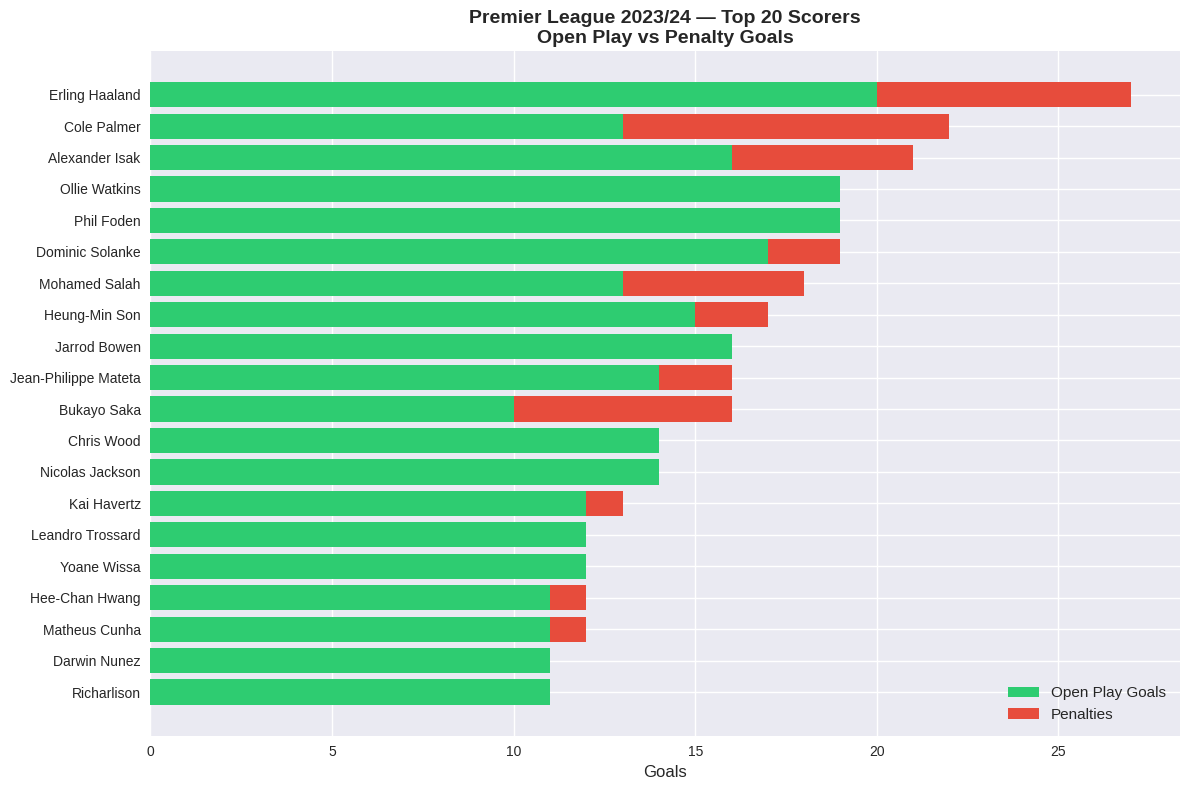

In [35]:
top_20 = df_qualified.nlargest(20, "Goals")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot non-penalty goals first
bars1 = ax.barh(top_20["Player"], top_20["non_penalty_goals"],
                color="#2ecc71", label="Open Play Goals")

# Stack penalties on top
bars2 = ax.barh(top_20["Player"], top_20["Penalties"],
                left=top_20["non_penalty_goals"],
                color="#e74c3c", label="Penalties")

ax.set_xlabel("Goals", fontsize=12)
ax.set_title("Premier League 2023/24 — Top 20 Scorers\nOpen Play vs Penalty Goals",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Chart 2 — Biggest overperformers vs position average

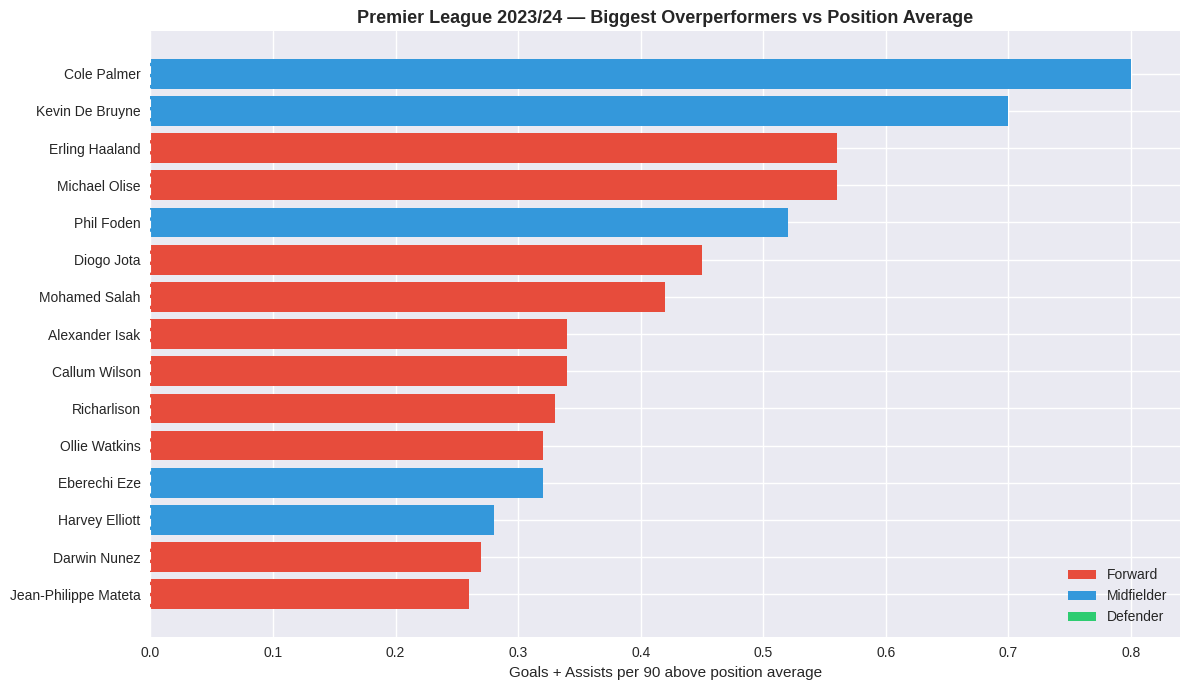

In [36]:
position_avg = df_complete.groupby("Position")["contributions_per_90"].mean().round(2)

df_complete["position_avg"] = df_complete["Position"].map(position_avg)
df_complete["vs_position_avg"] = round(df_complete["contributions_per_90"] - df_complete["position_avg"], 2)

# Plot top 15 overperformers
top_performers = df_complete.nlargest(15, "vs_position_avg")

fig, ax = plt.subplots(figsize=(12, 7))

colors = {"Forward": "#e74c3c", "Midfielder": "#3498db", "Defender": "#2ecc71"}
bar_colors = [colors[pos] for pos in top_performers["Position"]]

bars = ax.barh(top_performers["Player"], top_performers["vs_position_avg"],
               color=bar_colors)

ax.axvline(x=0, color="white", linewidth=1.5, linestyle="--")
ax.set_xlabel("Goals + Assists per 90 above position average", fontsize=11)
ax.set_title("Premier League 2023/24 — Biggest Overperformers vs Position Average",
             fontsize=13, fontweight="bold")

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Forward"),
                   Patch(facecolor="#3498db", label="Midfielder"),
                   Patch(facecolor="#2ecc71", label="Defender")]
ax.legend(handles=legend_elements, fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Chart 3 — Home vs away goal distribution + match results

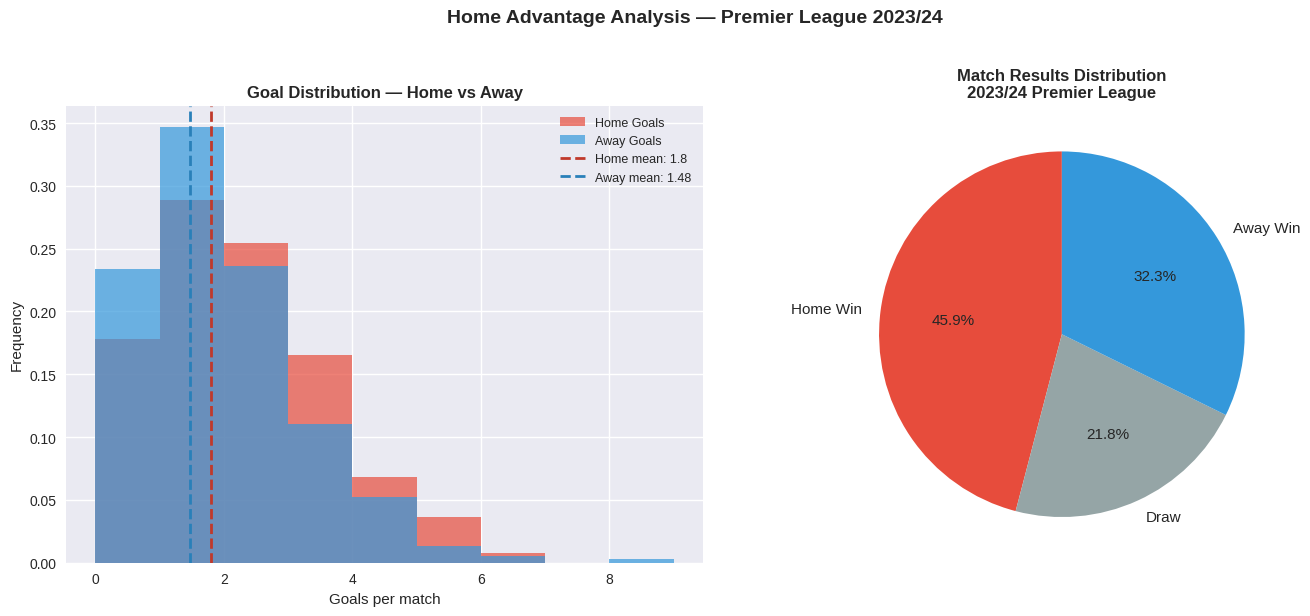

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — overlapping distributions
axes[0].hist(home_goals, bins=range(0, 10), alpha=0.7,
             color="#e74c3c", label="Home Goals", density=True)
axes[0].hist(away_goals, bins=range(0, 10), alpha=0.7,
             color="#3498db", label="Away Goals", density=True)
axes[0].axvline(home_goals.mean(), color="#c0392b",
                linewidth=2, linestyle="--", label=f"Home mean: {home_goals.mean().round(2)}")
axes[0].axvline(away_goals.mean(), color="#2980b9",
                linewidth=2, linestyle="--", label=f"Away mean: {away_goals.mean().round(2)}")
axes[0].set_xlabel("Goals per match", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Goal Distribution — Home vs Away", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Right — match results pie chart
results = ["Home Win", "Draw", "Away Win"]
counts = [175, 83, 123]
colors_pie = ["#e74c3c", "#95a5a6", "#3498db"]

axes[1].pie(counts, labels=results, colors=colors_pie, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Match Results Distribution\n2023/24 Premier League",
                  fontsize=12, fontweight="bold")

plt.suptitle("Home Advantage Analysis — Premier League 2023/24",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Chart 4 — Interactive: goals vs assists per 90 by position

In [38]:
fig = px.scatter(
    df_complete,
    x="goals_per_90",
    y="assists_per_90",
    color="Position",
    size="contributions_per_90",
    hover_name="Player",
    hover_data={"Team": True, "Goals": True, "Assists": True,
                "Minutes": True, "contributions_per_90": True,
                "goals_per_90": False, "assists_per_90": False},
    color_discrete_map={"Forward": "#e74c3c",
                        "Midfielder": "#3498db",
                        "Defender": "#2ecc71"},
    title="Premier League 2023/24 — Goals vs Assists per 90<br>Size = Total Contribution Rate",
    labels={"goals_per_90": "Goals per 90",
            "assists_per_90": "Assists per 90"},
    template="plotly_dark"
)

# Add position average lines
fig.add_hline(y=df_complete[df_complete["Position"]=="Midfielder"]["assists_per_90"].mean(),
              line_dash="dash", line_color="#3498db", opacity=0.5,
              annotation_text="Midfielder avg assists")

fig.add_vline(x=df_complete[df_complete["Position"]=="Forward"]["goals_per_90"].mean(),
              line_dash="dash", line_color="#e74c3c", opacity=0.5,
              annotation_text="Forward avg goals")

fig.update_traces(marker=dict(line=dict(width=1, color="white")))
fig.update_layout(height=600)
fig.show()

# Chart 5 — Interactive: home vs away goals across matchweeks


In [39]:
matchweek_stats = df_matches.groupby("Round").agg(
    avg_home=("Home Goals", "mean"),
    avg_away=("Away Goals", "mean")
).reset_index()

matchweek_stats["home_advantage"] = matchweek_stats["avg_home"] - matchweek_stats["avg_away"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=matchweek_stats["Round"],
    y=matchweek_stats["avg_home"],
    name="Home Goals",
    line=dict(color="#e74c3c", width=2),
    fill="tozeroy",
    fillcolor="rgba(231, 76, 60, 0.1)"
))

fig.add_trace(go.Scatter(
    x=matchweek_stats["Round"],
    y=matchweek_stats["avg_away"],
    name="Away Goals",
    line=dict(color="#3498db", width=2),
    fill="tozeroy",
    fillcolor="rgba(52, 152, 219, 0.1)"
))

fig.add_hline(y=1.80, line_dash="dash",
              line_color="#e74c3c", opacity=0.4,
              annotation_text="Season home avg: 1.80")
fig.add_hline(y=1.48, line_dash="dash",
              line_color="#3498db", opacity=0.4,
              annotation_text="Season away avg: 1.48")

fig.update_layout(
    title="Home vs Away Goals per Matchweek — Premier League 2023/24",
    xaxis_title="Matchweek",
    yaxis_title="Average Goals",
    template="plotly_dark",
    height=500,
    hovermode="x unified"
)

fig.show()

## 7. Executive Summary

**Dataset:** 298 Premier League players, 381 matches, 2023/24 season

**Key Findings:**

1. **Penalty inflation is significant** — Cole Palmer scored 40.9% of goals from penalties. Trossard and Richarlison are more efficient open-play scorers despite lower raw tallies.

2. **Position-adjusted metrics reveal a different hierarchy** — Cole Palmer and De Bruyne overperform their position average by 0.80 and 0.70 respectively, more than Haaland's 0.56. Midfielders are undervalued by goal-centric rankings.

3. **Injury-adjusted projections** — De Bruyne projected over a full season would produce 32 contributions, surpassing Salah's actual total of 30.

4. **Undervalued players identified** — Beto (Everton, 0.29 non-penalty per 90) and Alfie Doughty (Luton, 8 assists) represent strong value hidden by raw rankings.

5. **Home advantage is statistically proven** — p-value of 0.0009 across 381 matches. Home teams win 45.9% vs 32.3% for away teams. Finding is robust to outlier removal (p = 0.0003).

6. **Home advantage varies dramatically by team** — Aston Villa +1.06 goals per home match, Burnley -0.16. Context matters more than the league average.

**Tools used:** Python · Pandas · SQL (SQLite) · SciPy · Matplotlib · Seaborn · Plotly